In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/aliyafatma/plantvillege1/README.dataset.txt
/kaggle/input/datasets/aliyafatma/plantvillege1/README.roboflow.txt
/kaggle/input/datasets/aliyafatma/plantvillege1/valid/Cassava___mosaic_disease/624911036_jpg.rf.ac9da4d61a3cd99138a802daefd1229f.jpg
/kaggle/input/datasets/aliyafatma/plantvillege1/valid/Cassava___mosaic_disease/735041254_jpg.rf.cfa984d2b03def2bd55e9fe12b5363b6.jpg
/kaggle/input/datasets/aliyafatma/plantvillege1/valid/Cassava___mosaic_disease/535503922_jpg.rf.536e0d87f5644379a3279410d3e9a71f.jpg
/kaggle/input/datasets/aliyafatma/plantvillege1/valid/Cassava___mosaic_disease/4250754910_jpg.rf.c64189f92873ae3d824276f1c32c5a8f.jpg
/kaggle/input/datasets/aliyafatma/plantvillege1/valid/Cassava___mosaic_disease/3276292509_jpg.rf.889915ea0753493dc7944ddcd1d47765.jpg
/kaggle/input/datasets/aliyafatma/plantvillege1/valid/Cassava___mosaic_disease/131507385_jpg.rf.83d57d4fa4f398b8914ad5cdab101fc1.jpg
/kaggle/input/datasets/aliyafatma/plantvillege1/valid/Cassava___m

In [2]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [3]:
train_path ="/kaggle/input/datasets/aliyafatma/plantvillege1"

print(os.listdir(train_path))

['README.dataset.txt', 'README.roboflow.txt', 'valid', 'test', 'train']


In [4]:
import os
import pandas as pd
import json

In [5]:
dataset_path = "/kaggle/input/datasets/aliyafatma/plantvillege1"

train_dir = os.path.join(dataset_path, "train")

valid_dir = os.path.join(dataset_path, "valid")

test_dir = os.path.join(dataset_path, "test")

In [6]:
import os

print(os.path.exists(train_dir))
print(os.path.exists(valid_dir))
print(os.path.exists(test_dir))

True
True
True


In [7]:
class_names = sorted(os.listdir(train_dir))

print(class_names)

['Cassava___bacterial_blight', 'Cassava___brown_streak_disease', 'Cassava___green_mottle', 'Cassava___healthy', 'Cassava___mosaic_disease']


In [8]:

IMG_SIZE = 224

BATCH_SIZE = 32

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-06-01 08:43:15.206012: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780303395.458230      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780303395.527533      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780303396.119350      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780303396.119389      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780303396.119392      58 computation_placer.cc:177] computation placer alr

In [10]:
import os
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [12]:
val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [13]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

Found 12546 images belonging to 5 classes.


In [14]:
val_generator = val_datagen.flow_from_directory(
    valid_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1448 images belonging to 5 classes.


In [15]:
# Test Generator
test_datagen = ImageDataGenerator(
    rescale=1./255
)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1930 images belonging to 5 classes.


In [16]:
num_classes = len(train_generator.class_indices)

print("Classes:", train_generator.class_indices)
print("Number of Classes:", num_classes)

Classes: {'Cassava___bacterial_blight': 0, 'Cassava___brown_streak_disease': 1, 'Cassava___green_mottle': 2, 'Cassava___healthy': 3, 'Cassava___mosaic_disease': 4}
Number of Classes: 5


In [17]:
model = Sequential()

# Block 1
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same',
    input_shape=(224,224,3)
))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Block 2
model.add(Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Block 3
model.add(Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Block 4
model.add(Conv2D(
    256,
    (3,3),
    activation='relu',
    padding='same'
))
model.add(BatchNormalization())

# Classification Head
model.add(GlobalAveragePooling2D())

model.add(Dense(
    128,
    activation='relu'
))
model.add(Dropout(0.4))

model.add(Dense(
    num_classes,
    activation='softmax'
))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1780303413.746587      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780303413.752719      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,877 (1.62 MB)

 Trainable params: 422,917 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [18]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [20]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/30


I0000 00:00:1780303419.897390     133 service.cc:152] XLA service 0x7b4d58007310 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780303419.897440     133 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780303419.897447     133 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780303420.578219     133 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/393 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - accuracy: 0.1953 - loss: 1.7730   

I0000 00:00:1780303427.711716     133 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


321/393 ━━━━━━━━━━━━━━━━━━━━ 35s 496ms/step - accuracy: 0.3211 - loss: 1.5660

2026-06-01 08:46:28.069008: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-01 08:46:28.210917: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


393/393 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.3247 - loss: 1.5513
Epoch 1: val_accuracy improved from None to 0.27970, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
393/393 ━━━━━━━━━━━━━━━━━━━━ 221s 535ms/step - accuracy: 0.3449 - loss: 1.4779 - val_accuracy: 0.2797 - val_loss: 1.4833 - learning_rate: 0.0010
Epoch 2/30
393/393 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.4136 - loss: 1.3377
Epoch 2: val_accuracy improved from 0.27970 to 0.29627, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
393/393 ━━━━━━━━━━━━━━━━━━━━ 162s 411ms/step - accuracy: 0.4370 - loss: 1.3109 - val_accuracy: 0.2963 - val_loss: 1.8464 - learning_rate: 0.0010
Epoch 3/30
393/393 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.5035 - loss: 1.1960
Epoch 3: val_accuracy improved from 0.29627 to 0.43163, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
393/393 ━━━━━━━━━━━━━━━━━━━━ 159s 405

In [24]:
print("Best Validation Accuracy:",
      max(history.history['val_accuracy']))

Best Validation Accuracy: 0.7175414562225342


In [25]:
test_loss, test_acc = model.evaluate(test_generator)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - accuracy: 0.7197 - loss: 0.7376
Test Accuracy: 0.719689130783081
Test Loss: 0.7376163005828857


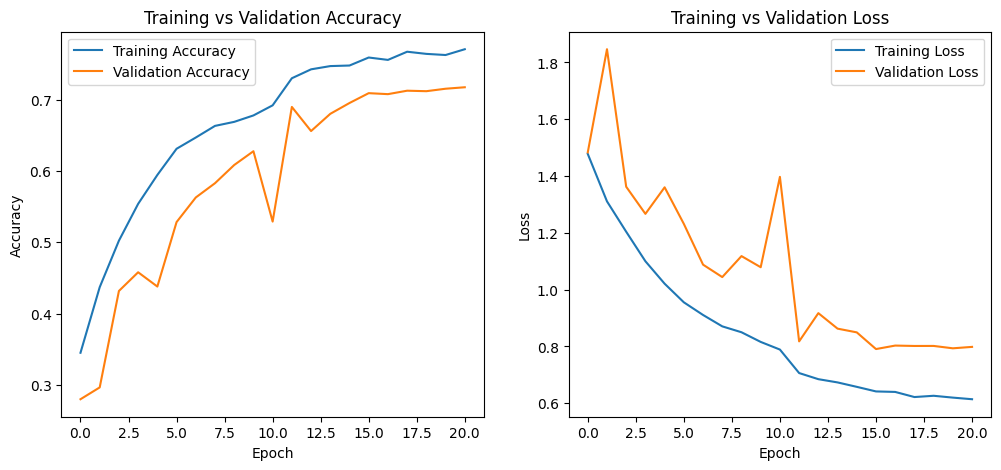

In [26]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()